In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sympy.parsing.mathematica import parse_mathematica
from scipy.integrate import solve_ivp

def two_body_equations(t, y):
    r1, r2 = y[:2], y[2:4]
    v1, v2 = y[4:6], y[6:8]

    R = np.linalg.norm(r1-r2)
    r = r1-r2
    n12 = (r1-r2) / R
    n21 = (r2-r1) / R
    
    # Newtonian acceleration
    a1N = G * m2 * n21 / R**2
    a2N = G * m1 * n12 / R**2

    PN_a1 = []
    PN_a2 = []

    # PN EoM corrections for body 1
    PN_a10str = "(G m2 r[0])/(R^2)^(3/2) + (2 G^2 m1 m2 R r[0] + 2 G^2 m2^2 R r[0] + 7 G m2 a2N[0] r[0]^4 + 14 G m2 a2N[0] r[0]^2 r[1]^2 + 7 G m2 a2N[0] r[1]^4 - 2 R a1N[1] r[0]^4 v1[0] v1[1] - 4 R a1N[1] r[0]^2 r[1]^2 v1[0] v1[1] + 6 G m2 r[1]^3 v1[0] v1[1] - 2 R a1N[1] r[1]^4 v1[0] v1[1] + 6 G m2 r[0]^2 r1[1] v1[0] v1[1] - 6 G m2 r[0]^2 r2[1] v1[0] v1[1] - 8 G m2 r[1]^3 v1[1] v2[0] - 8 G m2 r[0]^2 r1[1] v1[1] v2[0] + 8 G m2 r[0]^2 r2[1] v1[1] v2[0] + G m2 r1[0]^2 (R^2 a2N[0] + 3 r[0] v2[0]^2) + G m2 r2[0]^2 (R^2 a2N[0] + 3 r[0] v2[0]^2) - 6 G m2 r[1]^3 v1[0] v2[1] - 6 G m2 r[0]^2 r1[1] v1[0] v2[1] + 6 G m2 r[0]^2 r2[1] v1[0] v2[1] + 6 G m2 r[1]^3 v2[0] v2[1] + 6 G m2 r[0]^2 r1[1] v2[0] v2[1] - 6 G m2 r[0]^2 r2[1] v2[0] v2[1] + 3 G m2 r[0] r1[1]^2 v2[1]^2 - 6 G m2 r[0] r1[1] r2[1] v2[1]^2 + 3 G m2 r[0] r2[1]^2 v2[1]^2 + G m2 r2[0] (-3 R^2 v1[0]^2 + 6 R^2 v1[0] v2[0] - 2 R^2 v2[0]^2 - 6 r[0] r[1] v2[0] v2[1] + R^2 (2 c^2 - a2N[1] r1[1] + a2N[1] r2[1] + 3 v1[1]^2 -  8 v1[1] v2[1] + 4 v2[1]^2)) - G m2 r1[0] (-3 R^2 v1[0]^2 + 6 R^2 v1[0] v2[0] - 2 (R^2 - 3 r[0] r2[0]) v2[0]^2 - 6 r[0] r[1] v2[0] v2[1] + R^2 (2 c^2 - a2N[1] r1[1] + 2 a2N[0] r2[0] + a2N[1] r2[1] + 3 v1[1]^2 - 8 v1[1] v2[1] + 4 v2[1]^2)))/(R^4 (6 G m2 + 2 c^2 R + 3 R v1[0]^2 + R v1[1]^2))"
    PN_a10str = str(parse_mathematica(PN_a10str)).replace("r(0)","r[0]").replace("r(1)","r[1]").replace("r1(0)","r1[0]").replace("r1(1)","r1[1]").replace("r2(0)","r2[0]").replace("r2(1)","r2[1]").replace("v1(0)","v1[0]").replace("v1(1)","v1[1]").replace("v2(0)","v2[0]").replace("v2(1)","v2[1]").replace("a1N(0)","a1N[0]").replace("a1N(1)","a1N[1]").replace("a2N(0)","a2N[0]").replace("a2N(1)","a2N[1]")
    PN_a1.append(eval(PN_a10str))

    PN_a11str = "(G m2 r[1])/(R^2)^(3/2) + (r[0]^4 (7 G m2 a2N[1] - 2 R a1N[0] v1[0] v1[1]) + r[1]^4 (7 G m2 a2N[1] - 2 R a1N[0] v1[0] v1[1]) + G m2 r[1] (2 G m1 R + 2 G m2 R + 3 r1[0]^2 v2[0]^2 + 3 r2[0]^2 v2[0]^2 - 6 r[1] r2[0] v2[0] v2[1] + 3 r1[1]^2 v2[1]^2 - 6 r1[1] r2[1] v2[1]^2 + 3 r2[1]^2 v2[1]^2 + 6 r1[0] v2[0] (-r2[0] v2[0] + r[1] v2[1])) + G m2 r[1]^2 (a2N[1] r1[1]^2 + a2N[1] r2[1]^2 + 2 r[0] v1[0] (3 v1[1] - 4 v2[1]) + 6 r[0] v2[0] (-v1[1] + v2[1]) + r2[1] (2 c^2 - a2N[0] r1[0] + a2N[0] r2[0] + 3 v1[0]^2 - 3 v1[1]^2 - 8 v1[0] v2[0] + 4 v2[0]^2 + 6 v1[1] v2[1] - 2 v2[1]^2) - r1[1] (2 c^2 - a2N[0] r1[0] + a2N[0] r2[0] + 2 a2N[1] r2[1] + 3 v1[0]^2 - 3 v1[1]^2 - 8 v1[0] v2[0] + 4 v2[0]^2 + 6 v1[1] v2[1] - 2 v2[1]^2)) + r[0]^2 (14 G m2 a2N[1] r[1]^2 + G m2 a2N[1] r1[1]^2 +  G m2 a2N[1] r2[1]^2 - 4 R a1N[0] r[1]^2 v1[0] v1[1] + 6 G m2 r1[0] v1[0] v1[1] - 6 G m2 r2[0] v1[0] v1[1] - 6 G m2 r1[0] v1[1] v2[0] + 6 G m2 r2[0] v1[1] v2[0] - 8 G m2 r1[0] v1[0] v2[1] + 8 G m2 r2[0] v1[0] v2[1] + 6 G m2 r1[0] v2[0] v2[1] - 6 G m2 r2[0] v2[0] v2[1] + G m2 r2[1] (2 c^2 - a2N[0] r1[0] + a2N[0] r2[0] + 3 v1[0]^2 - 3 v1[1]^2 - 8 v1[0] v2[0] + 4 v2[0]^2 + 6 v1[1] v2[1] - 2 v2[1]^2) - G m2 r1[1] (2 c^2 - a2N[0] r1[0] + a2N[0] r2[0] + 2 a2N[1] r2[1] + 3 v1[0]^2 - 3 v1[1]^2 - 8 v1[0] v2[0] + 4 v2[0]^2 + 6 v1[1] v2[1] - 2 v2[1]^2)))/(R^4 (6 G m2 + 2 c^2 R + R v1[0]^2 + 3 R v1[1]^2))"
    PN_a11str = str(parse_mathematica(PN_a11str)).replace("r(0)","r[0]").replace("r(1)","r[1]").replace("r1(0)","r1[0]").replace("r1(1)","r1[1]").replace("r2(0)","r2[0]").replace("r2(1)","r2[1]").replace("v1(0)","v1[0]").replace("v1(1)","v1[1]").replace("v2(0)","v2[0]").replace("v2(1)","v2[1]").replace("a1N(0)","a1N[0]").replace("a1N(1)","a1N[1]").replace("a2N(0)","a2N[0]").replace("a2N(1)","a2N[1]")
    PN_a1.append(eval(PN_a11str))

    # PN EoM corrections for body 2
    PN_a20str = "-((G m1 r[0])/(R^2)^(3/2)) + (-2 G^2 m1^2 R r[0] - 2 G^2 m1 m2 R r[0] + 7 G m1 a1N[0] r[0]^4 + 14 G m1 a1N[0] r[0]^2 r[1]^2 + 7 G m1 a1N[0] r[1]^4 + G m1 r1[0]^2 (R^2 a1N[0] - 3 r[0] v1[0]^2) + G m1 r2[0]^2 (R^2 a1N[0] - 3 r[0] v1[0]^2) - 6 G m1 r[1]^3 v1[0] v1[1] - 6 G m1 r[0]^2 r1[1] v1[0] v1[1] + 6 G m1 r[0]^2 r2[1] v1[0] v1[1] - 3 G m1 r[0] r1[1]^2 v1[1]^2 + 6 G m1 r[0] r1[1] r2[1] v1[1]^2 - 3 G m1 r[0] r2[1]^2 v1[1]^2 + 6 G m1 r[1]^3 v1[1] v2[0] + 6 G m1 r[0]^2 r1[1] v1[1] v2[0] - 6 G m1 r[0]^2 r2[1] v1[1] v2[0] + 8 G m1 r[1]^3 v1[0] v2[1] + 8 G m1 r[0]^2 r1[1] v1[0] v2[1] - 8 G m1 r[0]^2 r2[1] v1[0] v2[1] - 2 R a2N[1] r[0]^4 v2[0] v2[1] - 4 R a2N[1] r[0]^2 r[1]^2 v2[0] v2[1] - 6 G m1 r[1]^3 v2[0] v2[1] - 2 R a2N[1] r[1]^4 v2[0] v2[1] - 6 G m1 r[0]^2 r1[1] v2[0] v2[1] + 6 G m1 r[0]^2 r2[1] v2[0] v2[1] + G m1 r2[0] (2 R^2 v1[0]^2 + v1[0] (6 r[0] r[1] v1[1] - 6 R^2 v2[0]) + R^2 (-2 c^2 - a1N[1] r1[1] + a1N[1] r2[1] - 4 v1[1]^2 + 3 v2[0]^2 + 8 v1[1] v2[1] - 3 v2[1]^2)) + G m1 r1[0] (-2 (R^2 - 3 r[0] r2[0]) v1[0]^2 + 6 v1[0] (-r[0] r[1] v1[1] + R^2 v2[0]) + R^2 (2 c^2 + a1N[1] r1[1] - 2 a1N[0] r2[0] - a1N[1] r2[1] + 4 v1[1]^2 - 3 v2[0]^2 - 8 v1[1] v2[1] + 3 v2[1]^2)))/(R^4 (6 G m1 + 2 c^2 R + 3 R v2[0]^2 + R v2[1]^2))"
    PN_a20str = str(parse_mathematica(PN_a20str)).replace("r(0)","r[0]").replace("r(1)","r[1]").replace("r1(0)","r1[0]").replace("r1(1)","r1[1]").replace("r2(0)","r2[0]").replace("r2(1)","r2[1]").replace("v1(0)","v1[0]").replace("v1(1)","v1[1]").replace("v2(0)","v2[0]").replace("v2(1)","v2[1]").replace("a1N(0)","a1N[0]").replace("a1N(1)","a1N[1]").replace("a2N(0)","a2N[0]").replace("a2N(1)","a2N[1]")
    PN_a2.append(eval(PN_a20str))

    PN_a21str = "-((G m1 r[1])/(R^2)^(3/2)) + (-G m1 r[1] (2 G m1 R + 2 G m2 R + 3 r1[0]^2 v1[0]^2 + 3 r2[0]^2 v1[0]^2 - 6 r[1] r2[0] v1[0] v1[1] + 3 r1[1]^2 v1[1]^2 - 6 r1[1] r2[1] v1[1]^2 + 3 r2[1]^2 v1[1]^2 + 6 r1[0] v1[0] (-r2[0] v1[0] + r[1] v1[1])) + r[0]^4 (7 G m1 a1N[1] - 2 R a2N[0] v2[0] v2[1]) + r[1]^4 (7 G m1 a1N[1] - 2 R a2N[0] v2[0] v2[1]) + G m1 r[1]^2 (a1N[1] r1[1]^2 + a1N[1] r2[1]^2 + 2 r[0] v2[0] (4 v1[1] - 3 v2[1]) - 6 r[0] v1[0] (v1[1] - v2[1]) + r1[1] (2 c^2 + a1N[0] r1[0] - a1N[0] r2[0] - 2 a1N[1] r2[1] + 4 v1[0]^2 - 2 v1[1]^2 - 8 v1[0] v2[0] + 3 v2[0]^2 + 6 v1[1] v2[1] - 3 v2[1]^2) + r2[1] (-2 c^2 - a1N[0] r1[0] + a1N[0] r2[0] - 4 v1[0]^2 + 2 v1[1]^2 + 8 v1[0] v2[0] - 3 v2[0]^2 - 6 v1[1] v2[1] + 3 v2[1]^2)) + r[0]^2 (14 G m1 a1N[1] r[1]^2 + G m1 a1N[1] r1[1]^2 + G m1 a1N[1] r2[1]^2 - 6 G m1 r1[0] v1[0] v1[1] + 6 G m1 r2[0] v1[0] v1[1] + 8 G m1 r1[0] v1[1] v2[0] - 8 G m1 r2[0] v1[1] v2[0] + 6 G m1 r1[0] v1[0] v2[1] - 6 G m1 r2[0] v1[0] v2[1] - 4 R a2N[0] r[1]^2 v2[0] v2[1] - 6 G m1 r1[0] v2[0] v2[1] + 6 G m1 r2[0] v2[0] v2[1] + G m1 r1[1] (2 c^2 + a1N[0] r1[0] - a1N[0] r2[0] - 2 a1N[1] r2[1] + 4 v1[0]^2 - 2 v1[1]^2 - 8 v1[0] v2[0] + 3 v2[0]^2 + 6 v1[1] v2[1] - 3 v2[1]^2) + G m1 r2[1] (-2 c^2 - a1N[0] r1[0] + a1N[0] r2[0] - 4 v1[0]^2 + 2 v1[1]^2 + 8 v1[0] v2[0] - 3 v2[0]^2 - 6 v1[1] v2[1] + 3 v2[1]^2)))/(R^4 (6 G m1 + 2 c^2 R + R v2[0]^2 + 3 R v2[1]^2))"
    PN_a21str = str(parse_mathematica(PN_a21str)).replace("r(0)","r[0]").replace("r(1)","r[1]").replace("r1(0)","r1[0]").replace("r1(1)","r1[1]").replace("r2(0)","r2[0]").replace("r2(1)","r2[1]").replace("v1(0)","v1[0]").replace("v1(1)","v1[1]").replace("v2(0)","v2[0]").replace("v2(1)","v2[1]").replace("a1N(0)","a1N[0]").replace("a1N(1)","a1N[1]").replace("a2N(0)","a2N[0]").replace("a2N(1)","a2N[1]")
    PN_a2.append(eval(PN_a21str))

    # Combine Newtonian and 1PN corrections
    a1 = a1N + PN_a1
    a2 = a2N + PN_a2

    # Equations of motion
    dr1dt = v1
    dr2dt = v2
    dv1dt = a1
    dv2dt = a2
    
    return np.concatenate([dr1dt, dr2dt, dv1dt, dv2dt])

def init():
    body1.set_data([], [])
    body2.set_data([], [])
    trail1.set_data([], [])
    trail2.set_data([], [])
    return body1, body2, trail1, trail2

def update(frame):
    body1.set_data(np.array([r1_sol[0, frame]]), np.array([r1_sol[1, frame]]))
    body2.set_data(np.array([r2_sol[0, frame]]), np.array([r2_sol[1, frame]]))
    trail1.set_data(np.array([r1_sol[0, :frame]]), np.array([r1_sol[1, :frame]]))
    trail2.set_data(np.array([r2_sol[0, :frame]]), np.array([r2_sol[1, :frame]]))
    return body1, body2, trail1, trail2


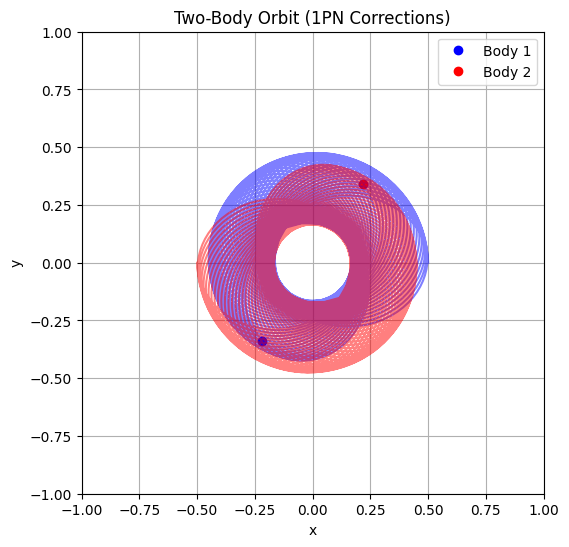

In [10]:
G = 1  # Gravitational constant (scaled)
c = 30  # Speed of light (scaled)

# Initial conditions
m1, m2 = 1, 1  # Masses of the two bodies
r1_init = np.array([0.5, 0])  # Initial position of body 1
r2_init = np.array([-0.5, 0])  # Initial position of body 2
v1_init = np.array([0, 0.5])  # Initial velocity of body 1
v2_init = np.array([0, -0.5])  # Initial velocity of body 2

# Center of mass frame
r_com = (m1 * r1_init + m2 * r2_init) / (m1 + m2)
v_com = (m1 * v1_init + m2 * v2_init) / (m1 + m2)
r1_init -= r_com
r2_init -= r_com
v1_init -= v_com
v2_init -= v_com

# Solve the equations of motion
t_span = (0, 120)
t_eval = np.linspace(*t_span, 2400)
y0 = np.concatenate([r1_init, r2_init, v1_init, v2_init])
sol = solve_ivp(two_body_equations, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-4, atol=1e-7)

# Extract positions
r1_sol, r2_sol = sol.y[:2], sol.y[2:4]

# Create animation
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Two-Body Orbit (1PN Corrections)')
ax.grid()
ax.set_aspect('equal')

body1, = ax.plot([], [], 'bo', label='Body 1')
body2, = ax.plot([], [], 'ro', label='Body 2')
trail1, = ax.plot([], [], 'b-', alpha=0.5)
trail2, = ax.plot([], [], 'r-', alpha=0.5)
ax.legend()

ani = animation.FuncAnimation(fig, update, frames=len(t_eval), init_func=init, blit=False)
ani.save('/home/dgw763/Documents/PN/1PNEqualMassLong.gif', writer='pillow', fps=30)

plt.show()

In the plot we see mostly what we expect. We have two bodies of equal mass orbiting each other, but the 1PN correction, we see precession in the orbits. However, there seems to be a little insprial. This is actually due to the tolerances in the Runge Kutta solver being too low. Insprial should come in until 2.5 order PN, so this inspiral is actually just computational error. See below for smaller tolerances

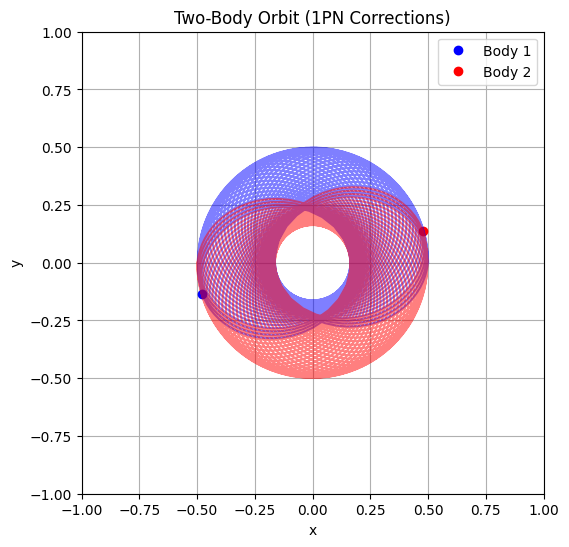

In [14]:
G = 1  # Gravitational constant (scaled)
c = 30  # Speed of light (scaled)

# Initial conditions
m1, m2 = 1, 1  # Masses of the two bodies
r1_init = np.array([0.5, 0])  # Initial position of body 1
r2_init = np.array([-0.5, 0])  # Initial position of body 2
v1_init = np.array([0, 0.5])  # Initial velocity of body 1
v2_init = np.array([0, -0.5])  # Initial velocity of body 2

# Center of mass frame
r_com = (m1 * r1_init + m2 * r2_init) / (m1 + m2)
v_com = (m1 * v1_init + m2 * v2_init) / (m1 + m2)
r1_init -= r_com
r2_init -= r_com
v1_init -= v_com
v2_init -= v_com

# Solve the equations of motion
t_span = (0, 100)
t_eval = np.linspace(*t_span, 2000)
y0 = np.concatenate([r1_init, r2_init, v1_init, v2_init])
sol = solve_ivp(two_body_equations, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-5, atol=1e-8)

# Extract positions
r1_sol, r2_sol = sol.y[:2], sol.y[2:4]

# Create animation
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Two-Body Orbit (1PN Corrections)')
ax.grid()
ax.set_aspect('equal')

body1, = ax.plot([], [], 'bo', label='Body 1')
body2, = ax.plot([], [], 'ro', label='Body 2')
trail1, = ax.plot([], [], 'b-', alpha=0.5)
trail2, = ax.plot([], [], 'r-', alpha=0.5)
ax.legend()

ani = animation.FuncAnimation(fig, update, frames=len(t_eval), init_func=init, blit=False)
ani.save('/home/dgw763/Documents/PN/1PNEqualMassHighRes.gif', writer='pillow', fps=30)

plt.show()

Now that we've made the tolerances smaller, we see that we no longer see this artificial inspiral. But this is just for equal mass ratio. Next we move to unequal mass ratio.

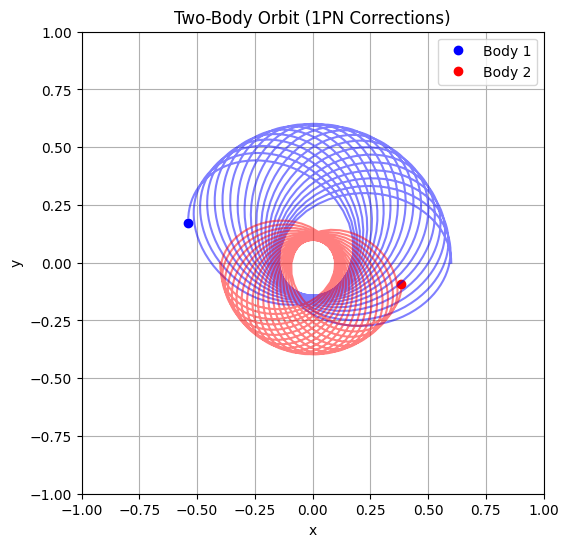

In [20]:
G = 1  # Gravitational constant (scaled)
c = 30  # Speed of light (scaled)

# Initial conditions
m1, m2 = 1, 1.5  # Masses of the two bodies
r1_init = np.array([0.5, 0])  # Initial position of body 1
r2_init = np.array([-0.5, 0])  # Initial position of body 2
v1_init = np.array([0, 0.5])  # Initial velocity of body 1
v2_init = np.array([0, -0.5])  # Initial velocity of body 2

# Center of mass frame
r_com = (m1 * r1_init + m2 * r2_init) / (m1 + m2)
v_com = (m1 * v1_init + m2 * v2_init) / (m1 + m2)
r1_init -= r_com
r2_init -= r_com
v1_init -= v_com
v2_init -= v_com

# Solve the equations of motion
t_span = (0, 40)
t_eval = np.linspace(*t_span, 1200)
y0 = np.concatenate([r1_init, r2_init, v1_init, v2_init])
sol = solve_ivp(two_body_equations, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-5, atol=1e-8)

# Extract positions
r1_sol, r2_sol = sol.y[:2], sol.y[2:4]

# Create animation
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Two-Body Orbit (1PN Corrections)')
ax.grid()
ax.set_aspect('equal')

body1, = ax.plot([], [], 'bo', label='Body 1')
body2, = ax.plot([], [], 'ro', label='Body 2')
trail1, = ax.plot([], [], 'b-', alpha=0.5)
trail2, = ax.plot([], [], 'r-', alpha=0.5)
ax.legend()

ani = animation.FuncAnimation(fig, update, frames=len(t_eval), init_func=init, blit=False)
ani.save('/home/dgw763/Documents/PN/1PNUnEqualMassHighRes.gif', writer='pillow', fps=30)

plt.show()

Cool, everything makes sense! Something to notice is that we've arbitrarily set the values of $c$ and $G$. This is because if we use the real values, the orbital precession is so small we can't see it in a reasonable amount of time. Alternatively I could have scaled the initial conditions rather than $c$ and $G$. But what happens when we no longer have that $v\ll c$ which is necessary for the PN expansion? Let's see...

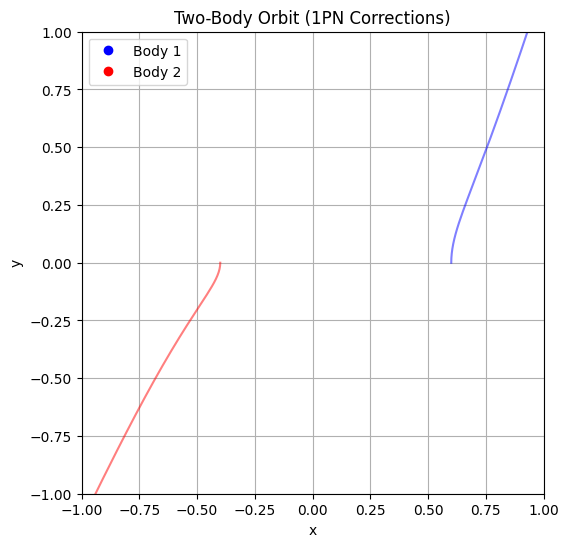

In [21]:
G = 1  # Gravitational constant (scaled)
c = 1  # Speed of light (scaled)

# Initial conditions
m1, m2 = 1, 1.5  # Masses of the two bodies
r1_init = np.array([0.5, 0])  # Initial position of body 1
r2_init = np.array([-0.5, 0])  # Initial position of body 2
v1_init = np.array([0, 0.5])  # Initial velocity of body 1
v2_init = np.array([0, -0.5])  # Initial velocity of body 2

# Center of mass frame
r_com = (m1 * r1_init + m2 * r2_init) / (m1 + m2)
v_com = (m1 * v1_init + m2 * v2_init) / (m1 + m2)
r1_init -= r_com
r2_init -= r_com
v1_init -= v_com
v2_init -= v_com

# Solve the equations of motion
t_span = (0, 10)
t_eval = np.linspace(*t_span, 300)
y0 = np.concatenate([r1_init, r2_init, v1_init, v2_init])
sol = solve_ivp(two_body_equations, t_span, y0, t_eval=t_eval, method='RK45', rtol=1e-4, atol=1e-7)

# Extract positions
r1_sol, r2_sol = sol.y[:2], sol.y[2:4]

# Create animation
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Two-Body Orbit (1PN Corrections)')
ax.grid()
ax.set_aspect('equal')

body1, = ax.plot([], [], 'bo', label='Body 1')
body2, = ax.plot([], [], 'ro', label='Body 2')
trail1, = ax.plot([], [], 'b-', alpha=0.5)
trail2, = ax.plot([], [], 'r-', alpha=0.5)
ax.legend()

ani = animation.FuncAnimation(fig, update, frames=len(t_eval), init_func=init, blit=False)
ani.save('/home/dgw763/Documents/PN/1PNUnEqualMassSmallc.gif', writer='pillow', fps=30)

plt.show()

Ah it seems like we just get something completely unphysical. The two bodies just fly away from one another. It's interesting to see where and how this appoximation breaks down.